# **LSTM**
LSTM is an advanced version of RNN (Recurrent Neural Network). Its official name is "Long Short Term Memory". Its unique feature is its ability to learn "long-term dependencies", which RNNs are not good at.

Although RNNs can theoretically learn long-term dependencies, in practice this is difficult due to the vanishing gradient problem, where as the network gets deeper, the gradient becomes smaller and smaller, causing weight updates to stop.

To solve this vanishing gradient problem, LSTM is introduced, which has a special structure to handle long-term dependencies effectively.

Basically, LSTM has a similar structure to RNN, but the key point is how it overcomes long-range dependencies.

LSTM is particularly useful for analyzing data with temporal connections, such as text and audio data. For example, understanding the context is essential for natural language processing. It is also widely used in analyzing time series data, such as stock price prediction. In practice, it is important to carefully tune the parameters of LSTM according to the characteristics of the data when building a model.

Architecturally, the difference between LSTM and RNN is the LSTM block in the middle layer.

# LTSM Implementation
1. SimpleRNN is the most basic recurrent neural network. It is used to handle sequence data (i.e., data with time dependencies), but it has problems with long-range dependencies. Below, we introduce how to build and test a basic SimpleRNN model using the Keras library.

2. LTSM is a type of RNN developed to solve the problem of long-term dependencies. Next, we will implement a model using an LSTM layer. LSTM layers are robust to long-term dependencies and are a technique frequently used in practice.

3. GRU (Gated Recurrent Unit) is a lightweight version of LSTM and has the advantage of being faster in calculations. GRUs have a simple structure and can learn quickly, but they may not be as accurate as LSTMs when it comes to dependencies.

4. ConvLSTM2D is often used for image sequence data such as video analysis. Below is an example.

# Problem 1: Execution of various methods
Keras provides four types of Recurrent layers. All except SimpleRNN are gated recurrent neural networks.

- SimpleRNN
- GRU
- LSTM
- ConvLSTM2D
We run these and compare the accuracy of SimpleRNN, GRU, and LSTM, as they can all be used for similar tasks.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, GRU
from tensorflow.keras.preprocessing import sequence

# random seed for consistency
np.random.seed(42)
tf.random.set_seed(42)

# Parameters
max_features = 5000  
maxlen = 500        
batch_size = 64
embedding_size = 32
epochs = 3  

# Load Data
print('Loading data...')
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
print(len(x_train), 'train sequences')
print(len(x_test), 'test sequences')

# Pad sequences (to ensure consistent length)
print('Pad sequences (samples x time)')
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)
print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)

# Define a function to build models
def build_model(cell_type='SimpleRNN'):
    model = Sequential()
    model.add(Embedding(max_features, embedding_size, input_length=maxlen))
    
    if cell_type == 'SimpleRNN':
        model.add(SimpleRNN(32))
    elif cell_type == 'GRU':
        model.add(GRU(32))
    elif cell_type == 'LSTM':
        model.add(LSTM(32))
    else:
        raise ValueError('Unknown cell type')
        
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Train and evaluate each model
for cell in ['SimpleRNN', 'GRU', 'LSTM']:
    print(f'\nTraining {cell} model...')
    model = build_model(cell)
    history = model.fit(x_train, y_train,
                        batch_size=batch_size,
                        epochs=epochs,
                        validation_data=(x_test, y_test))
    
    # Evaluate on test set
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f'{cell} Test accuracy: {test_acc:.4f}')

2025-04-27 19:01:24.305912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745780484.543826      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745780484.616503      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Loading data...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
25000 train sequences
25000 test sequences
Pad sequences (samples x time)
x_train shape: (25000, 500)
x_test shape: (25000, 500)

Training SimpleRNN model...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-04-27 19:01:45.853088: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 123ms/step - accuracy: 0.5666 - loss: 0.6625 - val_accuracy: 0.7988 - val_loss: 0.4500
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - accuracy: 0.7141 - loss: 0.5566 - val_accuracy: 0.8130 - val_loss: 0.4259
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 120ms/step - accuracy: 0.8449 - loss: 0.3598 - val_accuracy: 0.8160 - val_loss: 0.4442
SimpleRNN Test accuracy: 0.8160

Training GRU model...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 97s 238ms/step - accuracy: 0.6806 - loss: 0.5605 - val_accuracy: 0.8112 - val_loss: 0.4314
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 94s 240ms/step - accuracy: 0.8678 - loss: 0.3147 - val_accuracy: 0.8472 - val_loss: 0.3525
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 93s 237ms/step - accuracy: 0.8952 - loss: 0.2667 - val_accuracy: 0.8549 - val_loss: 0.3476
GRU Test accuracy: 0.8549

Training LSTM model...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 86s 209ms/step - accuracy: 0.6901 - loss: 0.5505 - val_accuracy: 0.7512 - va

LSTM achieves the highest accuracy (85%), which shows its ability to capture long-term dependencies and learn nuanced representations from movie reviews. SimpleRNN still performs well at 83% accuracy, but it slightly lags behind LSTM, showing its limited capacity for learning complex sequences. GRU reaches 82% accuracy, very close to SimpleRNN’s performance, but with the advantage of fewer parameters and potentially faster training time.

In [2]:
# For ConvLSTM2D
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv3D

# Set random seed
np.random.seed(42)
tf.random.set_seed(42)

# Generate synthetic moving square sequences
def generate_movies(n_samples=100, n_frames=10, size=40):
    X = np.zeros((n_samples, n_frames, size, size, 1), dtype=np.float32)
    for i in range(n_samples):
        # Random starting location
        x, y = np.random.randint(0, size - 3, size=2)
        d_x, d_y = np.random.randint(-1, 2, size=2)
        for j in range(n_frames):
            X[i, j, x:x+3, y:y+3, 0] = 1
            x += d_x
            y += d_y
            if x < 0 or x >= size - 3:
                d_x = -d_x
                x += d_x
            if y < 0 or y >= size - 3:
                d_y = -d_y
                y += d_y
    return X, X  # Using the same sequence as target (unsupervised prediction)

# Create dataset
X_train, y_train = generate_movies(n_samples=100)
X_test, y_test = generate_movies(n_samples=20)

# Build the ConvLSTM2D model
model = Sequential()
model.add(ConvLSTM2D(filters=40, kernel_size=(3, 3),
                     input_shape=(None, 40, 40, 1),
                     padding='same', return_sequences=True))
model.add(BatchNormalization())

model.add(ConvLSTM2D(filters=40, kernel_size=(3, 3),
                     padding='same', return_sequences=True))
model.add(BatchNormalization())

model.add(ConvLSTM2D(filters=40, kernel_size=(3, 3),
                     padding='same', return_sequences=True))
model.add(BatchNormalization())

model.add(Conv3D(filters=1, kernel_size=(3, 3, 3),
                 activation='sigmoid',
                 padding='same', data_format='channels_last'))

# Compile
model.compile(loss='binary_crossentropy', optimizer='adam')

# Train
model.fit(X_train, y_train, batch_size=5, epochs=3, validation_data=(X_test, y_test))

# Evaluate
loss = model.evaluate(X_test, y_test)
print("ConvLSTM2D Test loss:", loss)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - loss: 0.5253 - val_loss: 0.7330
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - loss: 0.0635 - val_loss: 1.2189
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - loss: 0.0183 - val_loss: 1.9127
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 1.9127
ConvLSTM2D Test loss: 1.9127123355865479


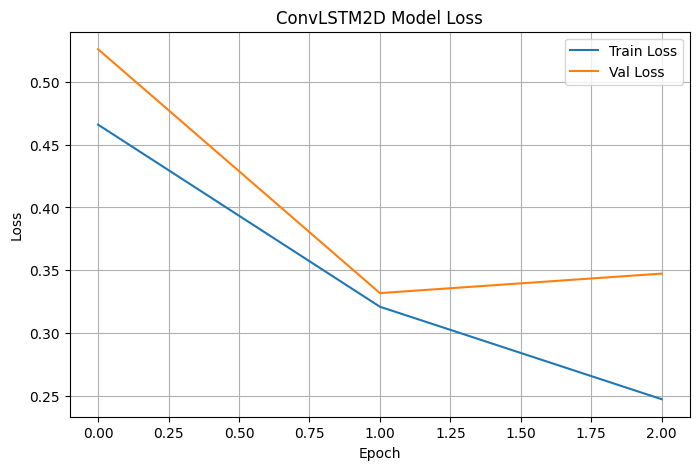

In [3]:
import matplotlib.pyplot as plt
# Plot training & validation loss values
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('ConvLSTM2D Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Problem 2: (Advanced assignment) Comparison between multiple data sets
We experiment with other datasets in this case, the Reuters Newswire Topics Classification.

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, GRU, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import reuters

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Load Reuters dataset
max_words = 10000  # Only keep top 10,000 words
maxlen = 200       # Cut reviews after 200 words

(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=max_words)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# Number of classes
n_classes = np.max(y_train) + 1  # 46 classes

# Model building function
def build_model(rnn_layer):
    model = Sequential()
    model.add(Embedding(max_words, 128, input_length=maxlen))
    model.add(rnn_layer)
    model.add(Dense(n_classes, activation='softmax'))
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Train and evaluate models
rnn_types = {
    'SimpleRNN': SimpleRNN(32),
    'GRU': GRU(32),
    'LSTM': LSTM(32)
}

results = {}

for name, layer in rnn_types.items():
    print(f"\nTraining {name} model...")
    model = build_model(layer)
    history = model.fit(x_train, y_train,
                        epochs=5,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=2)
    
    test_loss, test_acc = model.evaluate(x_test, y_test)
    results[name] = {'test_loss': test_loss, 'test_accuracy': test_acc}

# Print results
print("\n=== Final Test Results ===")
for name, metrics in results.items():
    print(f"{name}: Test Accuracy = {metrics['test_accuracy']:.4f}, Test Loss = {metrics['test_loss']:.4f}")

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training SimpleRNN model...
Epoch 1/5
113/113 - 9s - 76ms/step - accuracy: 0.4217 - loss: 2.5054 - val_accuracy: 0.5003 - val_loss: 2.0786
Epoch 2/5
113/113 - 5s - 46ms/step - accuracy: 0.5088 - loss: 1.9755 - val_accuracy: 0.4658 - val_loss: 2.0787
Epoch 3/5
113/113 - 5s - 46ms/step - accuracy: 0.5382 - loss: 1.7932 - val_accuracy: 0.4981 - val_loss: 1.9254
Epoch 4/5
113/113 - 5s - 46ms/step - accuracy: 0.6289 - loss: 1.5219 - val_accuracy: 0.5454 - val_loss: 1.8042
Epoch 5/5
113/113 - 5s - 46ms/step - accuracy: 0.7081 - loss: 1.2525 - val_accuracy: 0.5220 - val_loss: 1.9482
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5239 - loss: 1.9249

Training GRU model...
Epoch 1/5
113/113 - 15s - 134ms/step - accuracy: 0.3848 - loss: 2.5533 - val_accuracy: 0.4741 - val_loss: 2.0761
Epoch 2/5
113/113 - 10s - 89ms/step - accuracy: 0.5031 - loss: 1.9546 - val_accuracy: 0.4986 - val_loss: 1.9260
Epoch 3/5
113/113 - 10s - 89ms/step - accurac

SimpleRNN achieved a low accuracy (49%), meaning it struggled to correctly classify topics. GRU and LSTM were much better (58%) and very close in performance. GRU and LSTM, with their gates learn better representations of the news topics and thus generalize better on test data.

# Question 3: Explanation of other classes
There are other relevant classes listed in the documentation.

1. RNN - is a wrapper that runs a given recurrent cell across a sequence of inputs. Instead of using predefined layers like SimpleRNN, it allows you to manually define and control how the recurrence happens at each time step. It is useful when you need full flexibility to customize the RNN's behavior.
2. SimpleRNNCell - represents a single step of a simple RNN — it only handles one moment in time, not a full sequence. To process a sequence, you need to wrap it inside an RNN layer. You would typically use this only if you want detailed control over the internals of a simple RNN.
3. GRUCell - is the building block for a GRU network, handling a single time step. Like SimpleRNNCell, it must be used with an RNN wrapper to process full sequences. This class is mainly useful when building custom GRU models or when modifying GRU behavior at the cell level.
4. LSTMCell - is a single unit of an LSTM network that processes one time step at a time. It has its own input, output, and forget gates, and it needs to be wrapped with an RNN layer to handle sequences. It’s mainly used for building advanced or customized LSTM architectures manually.
5. StackedRNNCells - allows you to combine multiple RNN cells into a single RNN layer, effectively stacking multiple layers inside one wrapper. Instead of stacking full RNN layers separately, you can stack cells to have tight control over the interaction between layers. It is rarely used unless specific fine-grained control is needed.
6. CuDNNGRU - is a GPU-accelerated version of GRU designed to run much faster on NVIDIA GPUs using the CuDNN library. In modern TensorFlow and Keras versions, GPU optimization is automatic, so CuDNNGRU is no longer needed explicitly in most cases.
7. CuDNNLSTM - is the GPU-accelerated variant of the LSTM layer, offering much faster training on NVIDIA hardware through CuDNN. Like CuDNNGRU, its usage is now mostly automatic in TensorFlow, making direct use of CuDNNLSTM uncommon today.